In [2]:
# Imorting necessary libraries

import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau , EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import AdamW

# Image Size

In [1]:
img_size = 380

# Loading the dataset and splitting it into training and validation sets

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "D:/CNN/Cats_vs_Dogs_Classification/dogs-vs-cats/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_size, img_size),
    batch_size=4,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "D:/CNN/Cats_vs_Dogs_Classification/dogs-vs-cats/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_size, img_size),
    batch_size=4,
    label_mode='binary'
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


# Checking the distribution of classes

In [4]:
y_train = np.concatenate([y.numpy() for x, y in train_ds], axis=0)
np.unique(y_train, return_counts=True)

(array([0., 1.], dtype=float32), array([10038,  9962]))

In [5]:
y_val = np.concatenate([y.numpy() for x, y in val_ds], axis=0)
np.unique(y_val, return_counts=True)

(array([0., 1.], dtype=float32), array([2462, 2538]))

In [6]:
# Checking the shapes of the images and labels in the training dataset

for images, labels in train_ds.take(1):
    print(images.shape, labels.shape)

(4, 380, 380, 3) (4, 1)


TypeError: only integer scalar arrays can be converted to a scalar index

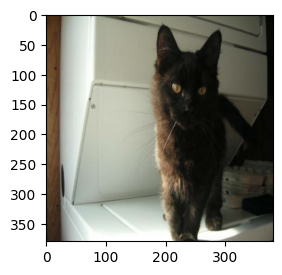

In [7]:
# Visualizing some images from the training dataset along with their labels

class_names = train_ds.class_names

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    
    for i in range(9):  # show 9 images
        ax = plt.subplot(3, 3,i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Model Using CNN

In [ ]:
# Building the CNN model for binary classification of cats and dogs

model = tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

d:\CNN\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, 
    patience=5,
    min_lr=1e-6)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)

model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=100,
    callbacks=[reduce_lr, early_stopping])

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 150ms/step - accuracy: 0.5688 - loss: 0.6751 - val_accuracy: 0.6426 - val_loss: 0.6333 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 150ms/step - accuracy: 0.6539 - loss: 0.6241 - val_accuracy: 0.6920 - val_loss: 0.5897 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 140ms/step - accuracy: 0.6939 - loss: 0.5854 - val_accuracy: 0.7202 - val_loss: 0.5552 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 138ms/step - accuracy: 0.7099 - loss: 0.5649 - val_accuracy: 0.7362 - val_loss: 0.5428 - learning_rate: 0.0010
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 138ms/step - accuracy: 0.7260 - loss: 0.5439 - val_accuracy: 0.7182 - val_loss: 0.5440 - learning_rate: 0.0010
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 138ms/step - accuracy: 0.7391 - loss: 0.5243 - val_accuracy: 0.7554 - val_loss: 0.5062 - learning_rate: 0.0010
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 140ms/step - accura

## Saving the CNN model weights for future use

In [12]:
model.save("cats_dogs_classifier.keras")

# Using Transfer Learning to Improve Accuracy

In [8]:
# Now using trasnfer learning to improve the model's performance

from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2)
])

In [10]:
model_base = EfficientNetB4(
    include_top=False,  
    weights='imagenet',
    input_shape=(img_size, img_size, 3)
)
model_base.trainable = False

In [11]:
model = tf.keras.Sequential([
    layers.Input(shape=(img_size, img_size, 3)),
    layers.Lambda(preprocess_input),  # Preprocessing layer for EfficientNet
    data_augmentation,
    model_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 12, 12, 1792)   │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       229,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,903,456 (68.30 MB)

 Trainable params: 229,633 (897.00 KB)

 Non-trainable params: 17,673,823 (67.42 MB)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, 
    patience=5,
    min_lr=1e-6)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=10,
    callbacks=[reduce_lr, early_stopping])

Epoch 1/10


625/625 ━━━━━━━━━━━━━━━━━━━━ 3224s 5s/step - accuracy: 0.9897 - loss: 0.0313 - val_accuracy: 0.9970 - val_loss: 0.0110 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3163s 5s/step - accuracy: 0.9938 - loss: 0.0176 - val_accuracy: 0.9974 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3145s 5s/step - accuracy: 0.9949 - loss: 0.0157 - val_accuracy: 0.9970 - val_loss: 0.0108 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3183s 5s/step - accuracy: 0.9949 - loss: 0.0150 - val_accuracy: 0.9964 - val_loss: 0.0129 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3192s 5s/step - accuracy: 0.9948 - loss: 0.0150 - val_accuracy: 0.9968 - val_loss: 0.0126 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3154s 5s/step - accuracy: 0.9956 - loss: 0.0130 - val_accuracy: 0.9972 - val_loss: 0.0130 - learning_rate: 0.0010


## Saving EfficientNetB4 Model

In [ ]:
# model.save('cats_dogs_transfer_learning_classifier.keras')

In [12]:

model.load_weights('cats_dogs_transfer_learning_classifier.keras')

d:\CNN\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Fine Tuning the Model

In [ ]:
for layer in model.layers:
    layer.trainable = False
    
for layer in model.layers[-30:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# ✅ Step 2: Re-compile with AdamW optimizer

model.compile(
    optimizer= AdamW(learning_rate=1e-5, weight_decay=1e-4),  # lower LR for fine-tuning
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
checkpoint = ModelCheckpoint(
    "best_model_fine-tuned.keras",  # file name for best model
    monitor="val_accuracy",          # save based on validation accuracy
    save_best_only=True,             # only best version
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

EPOCHS = 100
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint, reduce_lr, early_stop],
    verbose=1
)

# ✅ Step 5: Load the best saved model after training
fine_tuned_model = tf.keras.models.load_model("best_model_fine-tuned.keras")

Epoch 1/100


4492/5000 ━━━━━━━━━━━━━━━━━━━━ 24:19 3s/step - accuracy: 0.8994 - loss: 0.2334

In [21]:
testloss, test_acc = model.evaluate(val_ds)
print(f"Test accuracy: {test_acc:.4f}")

 21/157 ━━━━━━━━━━━━━━━━━━━━ 9:23 4s/step - accuracy: 0.9976 - loss: 0.0035

KeyboardInterrupt: 

In [20]:
predictions = model.predict(val_ds)


157/157 ━━━━━━━━━━━━━━━━━━━━ 646s 4s/step


In [22]:
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = np.concatenate([y for x, y in val_ds], axis=0)

In [23]:
classes = val_ds.class_names
print("Classes:", classes)

Classes: ['cats', 'dogs']


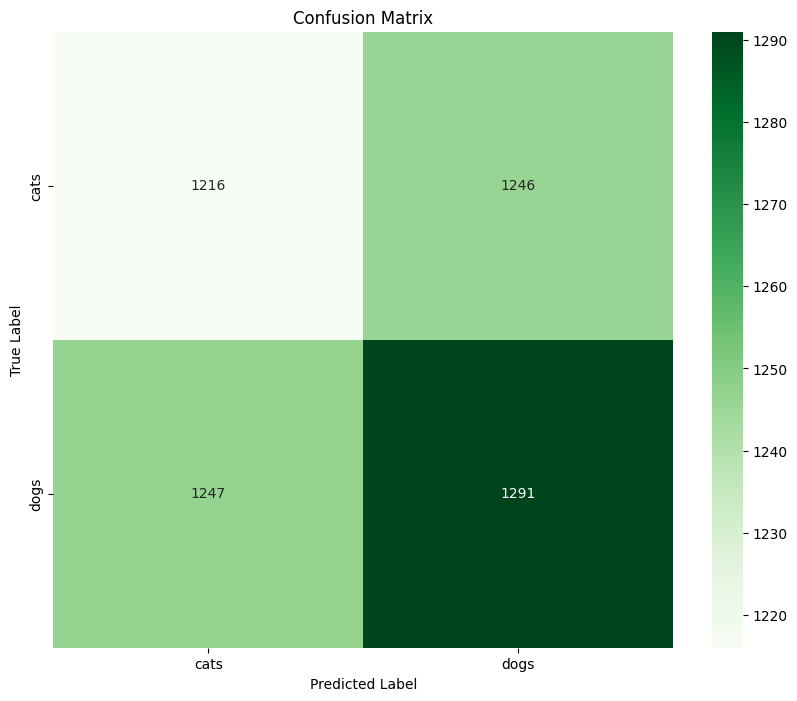

In [25]:
# Confusion Matrix to better understand the model's performance across different classes
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(np.unique(y_pred, return_counts=True))
print(np.unique(y_true, return_counts=True))

(array([0, 1]), array([2463, 2537]))
(array([0., 1.], dtype=float32), array([2462, 2538]))


In [ ]:
# # Evaluating the model on the test set
# test_data = tf.keras.utils.image_dataset_from_directory(
#     "D:/CNN/Cats_vs_Dogs_Classification/dogs-vs-cats/test1",
#     image_size=(img_size, img_size),
#     batch_size=32,
#     labels=None,   
#     shuffle=False
# )  

Found 12500 files.


In [ ]:
# import numpy as np

# for images in test_data.take(1):
#     idx = np.random.randint(0, images.shape[0])
#     img = images[idx:idx+1]

#     pred = model.predict(img)
#     label = int(pred.item() > 0.5)

#     print("Predicted class:", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Predicted class: 0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


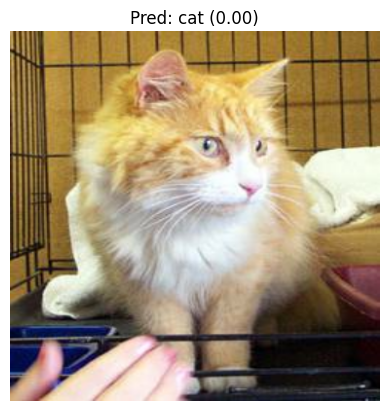

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


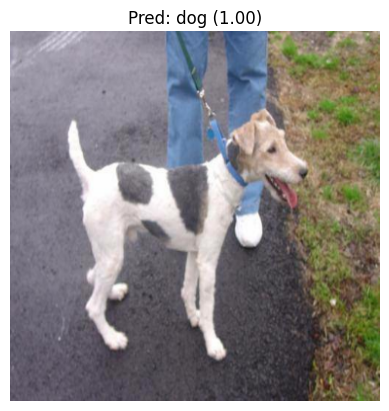

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# class_names = ["cat", "dog"]   # adjust if your order is different

# for images in test_data.take(2):
#     idx = np.random.randint(0, images.shape[0])
#     img = images[idx:idx+1]

#     pred = model.predict(img)
#     prob = pred.item()
#     label = int(prob > 0.5)

#     # Show image
#     plt.imshow(images[idx].numpy().astype("uint8"))
#     plt.title(f"Pred: {class_names[label]} ({prob:.2f})")
#     plt.axis("off")
#     plt.show()